# Lab 01 — Phân tích và xử lý tín hiệu âm thanh số

**MSSV:** 2351260695  
**Họ tên:** Lỗ Anh Việt

Notebook này được triển khai theo đúng thứ tự A → G trong đề bài.

## A. Đọc và kiểm tra dữ liệu âm thanh

Notebook tự tạo và sử dụng ba thư mục `audio/input/`, `audio/output/` và `figures/`. Hãy đặt tệp WAV/MP3 cần phân tích vào `audio/input/`; tệp đầu tiên theo thứ tự tên sẽ được chọn. Nếu `audio/input/` còn trống, notebook dùng audio test tái lập ở `audio/generated_conversation.wav`.

In [13]:
from pathlib import Path
import numpy as np
from pydub import AudioSegment

# Cấu trúc thư mục chuẩn của Lab. Chạy notebook từ thư mục Lab01.
project_root = Path.cwd().resolve()
audio_dir = project_root / 'audio'
input_dir = audio_dir / 'input'
output_dir = audio_dir / 'output'
figures_dir = project_root / 'figures'
for folder in (input_dir, output_dir, figures_dir):
    folder.mkdir(parents=True, exist_ok=True)

# Đặt file WAV/MP3 cá nhân vào audio/input/. Nếu thư mục còn trống,
# dùng file test tái lập ở audio/generated_conversation.wav.
candidates = sorted(
    p for p in input_dir.iterdir()
    if p.is_file() and p.suffix.lower() in {'.wav', '.mp3', '.flac', '.ogg', '.m4a'}
) if input_dir.exists() else []
default_audio_path = audio_dir / 'generated_conversation.wav'
audio_path = candidates[0] if candidates else default_audio_path
if not audio_path.exists():
    raise FileNotFoundError(f'Không tìm thấy tệp âm thanh: {audio_path}')

audio = AudioSegment.from_file(audio_path)
sample_rate = audio.frame_rate
channels = audio.channels
sample_width_bytes = audio.sample_width
sample_bits = 8 * sample_width_bytes
duration_s = len(audio) / 1000.0

# Pydub trả mẫu theo thứ tự xen kẽ: L0, R0, L1, R1, ... nếu là stereo.
raw = np.asarray(audio.get_array_of_samples(), dtype=np.float64)
raw = raw.reshape(-1, channels)
full_scale = float(2 ** (sample_bits - 1))
x_channels = raw / full_scale
x_mono = x_channels.mean(axis=1)
x_mono = np.clip(x_mono, -1.0, 1.0)

file_size_bytes = audio_path.stat().st_size
pcm_bitrate_bps = sample_rate * sample_bits * channels
metadata = {
    'file': str(audio_path),
    'file_size_bytes': file_size_bytes,
    'sample_rate_hz': sample_rate,
    'channels': channels,
    'duration_s': duration_s,
    'sample_bits': sample_bits,
    'samples_per_channel': len(x_mono),
    'pcm_bitrate_kbps': pcm_bitrate_bps / 1000,
}

print('Metadata:')
for key, value in metadata.items():
    print(f'  {key}: {value}')
print(f'\nThư mục input : {input_dir}')
print(f'Thư mục output: {output_dir}')
print(f'Thư mục figures: {figures_dir}')
print(f'\nMiền giá trị mono sau chuẩn hóa: [{x_mono.min():.4f}, {x_mono.max():.4f}]')
print(f'Kích thước mảng mono: {x_mono.shape}')

Metadata:
  file: /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab01_2351260695_LoAnhViet/audio/generated_conversation.wav
  file_size_bytes: 1340684
  sample_rate_hz: 44100
  channels: 1
  duration_s: 15.2
  sample_bits: 16
  samples_per_channel: 670320
  pcm_bitrate_kbps: 705.6

Thư mục input : /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab01_2351260695_LoAnhViet/audio/input
Thư mục output: /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab01_2351260695_LoAnhViet/audio/output
Thư mục figures: /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab01_2351260695_LoAnhViet/figures

Miền giá trị mono sau chuẩn hóa: [-0.8481, 0.8500]
Kích thước mảng mono: (670320,)


### Nhận xét bước A

- `sample_rate` là số mẫu mỗi giây; tần số Nyquist của tệp là `sample_rate / 2`.
- `x_channels` giữ dữ liệu từng kênh; `x_mono` là trung bình các kênh và được dùng cho các phân tích tiếp theo.
- Sau chuẩn hóa, biên độ lý tưởng nằm trong `[-1, 1]`; các đại lượng peak, RMS, năng lượng và clipping được tính ở phần B.

## B. Phân tích miền thời gian

Phần này phân tích tín hiệu trong miền thời gian thông qua waveform, Peak, RMS và Energy.
Waveform toàn bộ tệp được vẽ theo thời gian; các giá trị peak, RMS và energy được tính trên tín hiệu mono đã chuẩn hóa.

In [14]:
# Các đại lượng miền thời gian

peak = np.max(np.abs(x_mono))
rms = np.sqrt(np.mean(x_mono**2))
energy = np.sum(x_mono**2)

print(f"Peak   = {peak:.6f}")
print(f"RMS    = {rms:.6f}")
print(f"Energy = {energy:.2f}")

# Kiểm tra clipping
if peak >= 0.999:
    print("Có mẫu đạt gần full-scale -> có nguy cơ clipping.")
else:
    print("Không phát hiện clipping rõ ràng.")

Peak   = 0.849976
RMS    = 0.062291
Energy = 2600.96
Không phát hiện clipping rõ ràng.


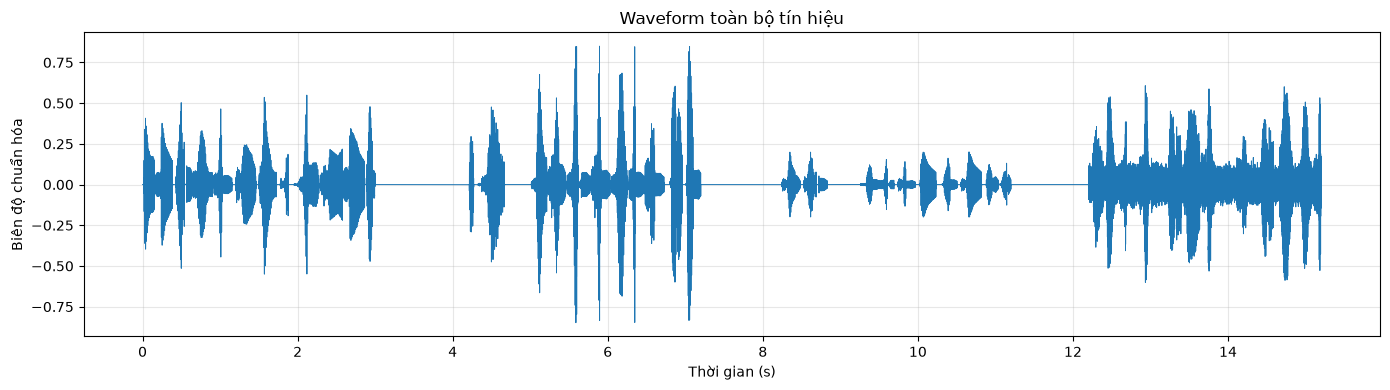

In [15]:
import matplotlib.pyplot as plt
# Tạo trục thời gian
time = np.arange(len(x_mono)) / sample_rate

# Vẽ waveform toàn bộ tín hiệu
plt.figure(figsize=(14, 4))

plt.plot(time, x_mono, linewidth=0.7)

plt.title("Waveform toàn bộ tín hiệu")
plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ chuẩn hóa")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### So sánh hai đoạn có đặc tính khác nhau

Với audio test mặc định, các đoạn được sinh theo timeline cố định nên ta so sánh đoạn nói lớn (4,2–7,2 s), nói nhỏ (8,2–11,2 s) và white noise (12,2–15,2 s). Nếu thay bằng file riêng trong `audio/input/`, code tự chia file thành ba đoạn thời lượng gần bằng nhau.

Đoạn                          Peak       RMS        Energy
Nói lớn (4.2–7.2 s)            0.849976  0.091347  1103.94
Nói nhỏ (8.2–11.2 s)           0.199982  0.022787  68.69
Có white noise (12.2–15.2 s)   0.607391  0.083190  915.59


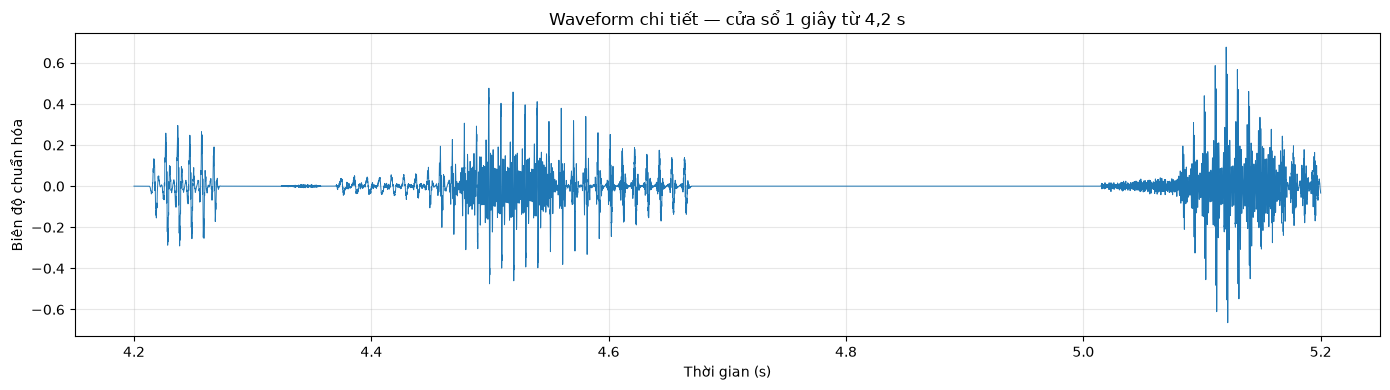

In [16]:
if audio_path.resolve() == default_audio_path.resolve() and duration_s >= 15.0:
    comparison_segments = {
        'Nói lớn (4.2–7.2 s)': (4.2, 7.2),
        'Nói nhỏ (8.2–11.2 s)': (8.2, 11.2),
        'Có white noise (12.2–15.2 s)': (12.2, min(15.2, duration_s)),
    }
else:
    segment_length = duration_s / 3
    comparison_segments = {
        'Đoạn 1': (0.0, segment_length),
        'Đoạn 2': (segment_length, 2 * segment_length),
        'Đoạn 3': (2 * segment_length, duration_s),
    }
print('Đoạn                          Peak       RMS        Energy')
for label, (start_s, end_s) in comparison_segments.items():
    left = int(start_s * sample_rate)
    right = min(int(end_s * sample_rate), len(x_mono))
    values = x_mono[left:right]
    print(f'{label:30s} {np.max(np.abs(values)):.6f}  {np.sqrt(np.mean(values ** 2)):.6f}  {np.sum(values ** 2):.2f}')

first_segment_start, first_segment_end = next(iter(comparison_segments.values()))
detail_start_s = first_segment_start
detail_duration_s = min(1.0, first_segment_end - first_segment_start)
detail_left = int(detail_start_s * sample_rate)
detail_right = detail_left + int(detail_duration_s * sample_rate)
detail_time = np.arange(detail_right - detail_left) / sample_rate + detail_start_s
plt.figure(figsize=(14, 4))
plt.plot(detail_time, x_mono[detail_left:detail_right], linewidth=0.7)
plt.title('Waveform chi tiết — cửa sổ 1 giây từ 4,2 s')
plt.xlabel('Thời gian (s)')
plt.ylabel('Biên độ chuẩn hóa')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'waveform_segment.png', dpi=160, bbox_inches='tight')
plt.show()

### Nhận xét bước B

Đoạn nói lớn có RMS và năng lượng cao hơn đoạn nói nhỏ, thể hiện mức năng lượng hiệu dụng khác nhau. Đoạn có white noise có nền phổ và RMS tăng so với đoạn yên tĩnh; các giá trị này được dùng làm bằng chứng định lượng thay cho nhận xét chỉ dựa trên nghe.

## C. Phân tích miền tần số bằng FFT

Với audio test mặc định dài khoảng 15,2 giây, code chọn đoạn 1 giây bắt đầu từ 4,5 giây thay cho đoạn 45–46 giây trong case study nhạc dài 93 giây. Nếu file riêng ngắn hơn, vị trí đoạn được tự điều chỉnh. Đoạn được nhân cửa sổ Hamming trước khi tính FFT.

Đoạn FFT: 4.500–5.500 s (44100 mẫu)
NFFT=2048: Δf=21.533 Hz
  Đỉnh: 882.9 Hz (-62.3 dB relative)
  Đỉnh: 495.3 Hz (-63.9 dB relative)
  Đỉnh: 193.8 Hz (-73.6 dB relative)
NFFT=8192: Δf=5.383 Hz
  Đỉnh: 387.6 Hz (-54.3 dB relative)
  Đỉnh: 96.9 Hz (-59.5 dB relative)
  Đỉnh: 882.9 Hz (-61.8 dB relative)


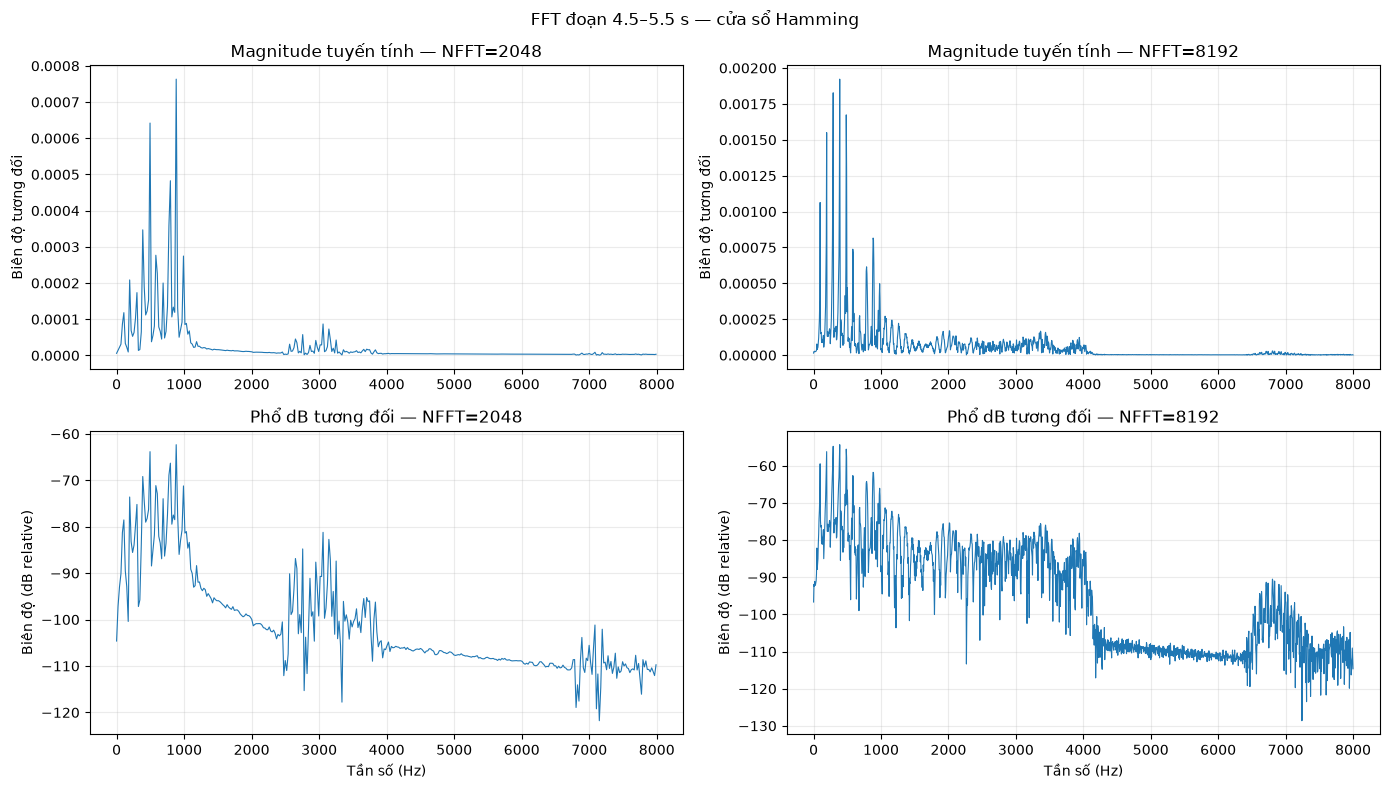

In [17]:
from scipy.signal import find_peaks

segment_duration_s = min(1.0, duration_s)
segment_start_s = 4.5 if duration_s >= 5.5 else max(0.0, (duration_s - segment_duration_s) / 2)
start = int(round(segment_start_s * sample_rate))
stop = min(len(x_mono), start + int(round(segment_duration_s * sample_rate)))
segment = x_mono[start:stop]
window = np.hamming(len(segment))

nfft_values = (2048, 8192)
fft_results = {}
for nfft in nfft_values:
    spectrum = np.fft.rfft(segment * window, n=nfft)
    frequencies = np.fft.rfftfreq(nfft, d=1 / sample_rate)
    magnitude = 2 * np.abs(spectrum) / np.sum(window)
    magnitude[0] /= 2
    magnitude_db = 20 * np.log10(np.maximum(magnitude, 1e-12))
    peaks, _ = find_peaks(magnitude, distance=max(1, nfft // 200), prominence=max(np.max(magnitude) * 0.01, 1e-6))
    top_peaks = peaks[np.argsort(magnitude[peaks])[-3:]] if len(peaks) else np.array([], dtype=int)
    fft_results[nfft] = (frequencies, magnitude, magnitude_db, top_peaks)

print(f'Đoạn FFT: {segment_start_s:.3f}–{stop / sample_rate:.3f} s ({len(segment)} mẫu)')
for nfft in nfft_values:
    frequencies, magnitude, magnitude_db, top_peaks = fft_results[nfft]
    print(f'NFFT={nfft}: Δf={sample_rate / nfft:.3f} Hz')
    for index in top_peaks[::-1]:
        print(f'  Đỉnh: {frequencies[index]:.1f} Hz ({magnitude_db[index]:.1f} dB relative)')

plot_max_hz = min(sample_rate / 2, 8000)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for column, nfft in enumerate(nfft_values):
    frequencies, magnitude, magnitude_db, top_peaks = fft_results[nfft]
    mask = frequencies <= plot_max_hz
    axes[0, column].plot(frequencies[mask], magnitude[mask], linewidth=0.8)
    axes[0, column].set_title(f'Magnitude tuyến tính — NFFT={nfft}')
    axes[0, column].set_ylabel('Biên độ tương đối')
    axes[0, column].grid(alpha=0.25)
    axes[1, column].plot(frequencies[mask], magnitude_db[mask], linewidth=0.8)
    axes[1, column].set_title(f'Phổ dB tương đối — NFFT={nfft}')
    axes[1, column].set_xlabel('Tần số (Hz)')
    axes[1, column].set_ylabel('Biên độ (dB relative)')
    axes[1, column].grid(alpha=0.25)
fig.suptitle(f'FFT đoạn {segment_start_s:.1f}–{stop / sample_rate:.1f} s — cửa sổ Hamming')
fig.tight_layout()
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / 'fft.png', dpi=160, bbox_inches='tight')
plt.show()

### Nhận xét FFT

Đoạn tín hiệu được chọn có năng lượng tập trung chủ yếu ở vùng tần số thấp.
Với NFFT = 2048, khoảng cách giữa các frequency bin là 21.533 Hz; khi tăng 
NFFT lên 8192, khoảng cách giảm xuống 5.383 Hz nên phổ được biểu diễn mịn 
và chi tiết hơn.

Các đỉnh phổ nổi bật được xác định tự động cho thấy tín hiệu speech chứa 
nhiều thành phần tần số khác nhau. Việc tăng NFFT làm tăng mật độ lấy mẫu 
của phổ, nhưng do độ dài đoạn tín hiệu vẫn giữ nguyên 1 giây nên không thể 
kết luận rằng độ phân giải tần số thực tăng tương ứng.

## D. STFT và spectrogram

Cấu hình chuẩn dùng frame khoảng 25 ms và hop 10 ms. Phần so sánh sử dụng toàn bộ file đầu vào; với audio test mặc định 15,2 giây, điều này giữ cả các đoạn speech bình thường, speech lớn/nhỏ và speech kèm white noise từ khoảng 12 giây trở đi. Ba frame length 10/25/50 ms được tính trên cùng dữ liệu, cùng hop và cùng `NFFT` để kiểm soát thí nghiệm.

Frame=10 ms: L= 441 mẫu, H= 441 mẫu, overlap=   0 mẫu
Frame=25 ms: L=1102 mẫu, H= 441 mẫu, overlap= 661 mẫu
Frame=50 ms: L=2205 mẫu, H= 441 mẫu, overlap=1764 mẫu


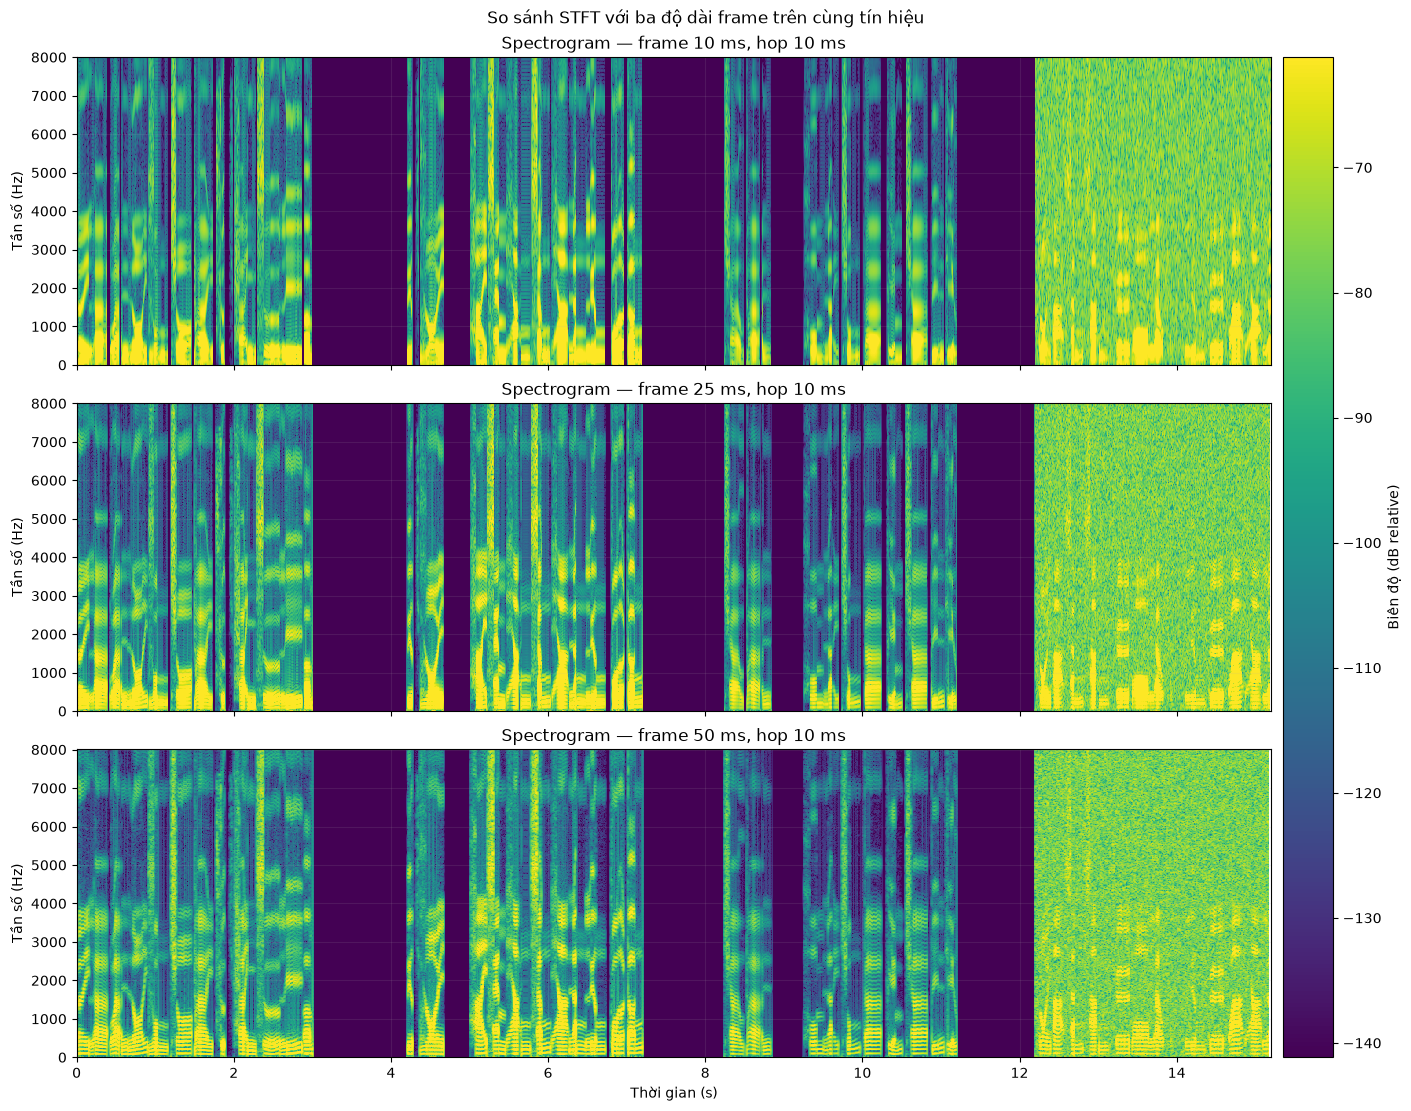

In [18]:
from scipy import signal

stft_duration_s = duration_s
stft_start_s = 0.0
stft_start = int(stft_start_s * sample_rate)
stft_stop = min(len(x_mono), stft_start + int(stft_duration_s * sample_rate))
stft_signal = x_mono[stft_start:stft_stop]

hop_ms = 10
hop_samples = round(hop_ms * 1e-3 * sample_rate)
frame_lengths_ms = (10, 25, 50)
nfft_stft = 4096
spectrograms = {}

for frame_ms in frame_lengths_ms:
    frame_samples = round(frame_ms * 1e-3 * sample_rate)
    frequencies, times, magnitude = signal.spectrogram(
        stft_signal,
        fs=sample_rate,
        window='hamming',
        nperseg=frame_samples,
        noverlap=max(0, frame_samples - hop_samples),
        nfft=nfft_stft,
        mode='magnitude',
    )
    magnitude_db = 20 * np.log10(np.maximum(magnitude, 1e-12))
    spectrograms[frame_ms] = (frequencies, times, magnitude_db)
    print(
        f'Frame={frame_ms:>2} ms: L={frame_samples:>4} mẫu, '
        f'H={hop_samples:>4} mẫu, overlap={frame_samples - hop_samples:>4} mẫu'
    )

# Dùng chung color scale để so sánh đúng giữa ba spectrogram.
all_db = np.concatenate([item[2].ravel() for item in spectrograms.values()])
vmax = np.percentile(all_db, 99)
vmin = vmax - 80
display_max_hz = min(sample_rate / 2, 8000)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True, sharey=True, constrained_layout=True)
image = None
for axis, frame_ms in zip(axes, frame_lengths_ms):
    frequencies, times, magnitude_db = spectrograms[frame_ms]
    frequency_mask = frequencies <= display_max_hz
    image = axis.pcolormesh(
        times + stft_start_s,
        frequencies[frequency_mask],
        magnitude_db[frequency_mask],
        shading='auto',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axis.set_title(f'Spectrogram — frame {frame_ms} ms, hop {hop_ms} ms')
    axis.set_ylabel('Tần số (Hz)')
    axis.grid(alpha=0.12)
axes[-1].set_xlabel('Thời gian (s)')
fig.colorbar(image, ax=axes, label='Biên độ (dB relative)', pad=0.01)
fig.suptitle('So sánh STFT với ba độ dài frame trên cùng tín hiệu')
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / 'spectrogram.png', dpi=160, bbox_inches='tight')
plt.show()

### Nhận xét bước D

Frame 25 ms và hop 10 ms là cấu hình chuẩn cho phân tích tiếng nói. Frame 10 ms bám sát các thay đổi nhanh theo thời gian nhưng các dải tần rộng và kém sắc hơn; frame 50 ms cho dải tần hẹp, rõ hơn nhưng làm transient bị kéo dài theo thời gian. Trong hình, vùng sáng biểu thị năng lượng lớn hơn; thang màu được giữ cố định giữa ba panel để việc so sánh không bị sai lệch bởi cách hiển thị.

## E. Thí nghiệm cửa sổ

Giữ nguyên đoạn FFT 1 giây ở phần C và `NFFT = 8192`, sau đó so sánh cửa sổ rectangular với Hamming. Phổ được chuẩn hóa theo tổng hệ số cửa sổ; trục dB là dB tương đối.

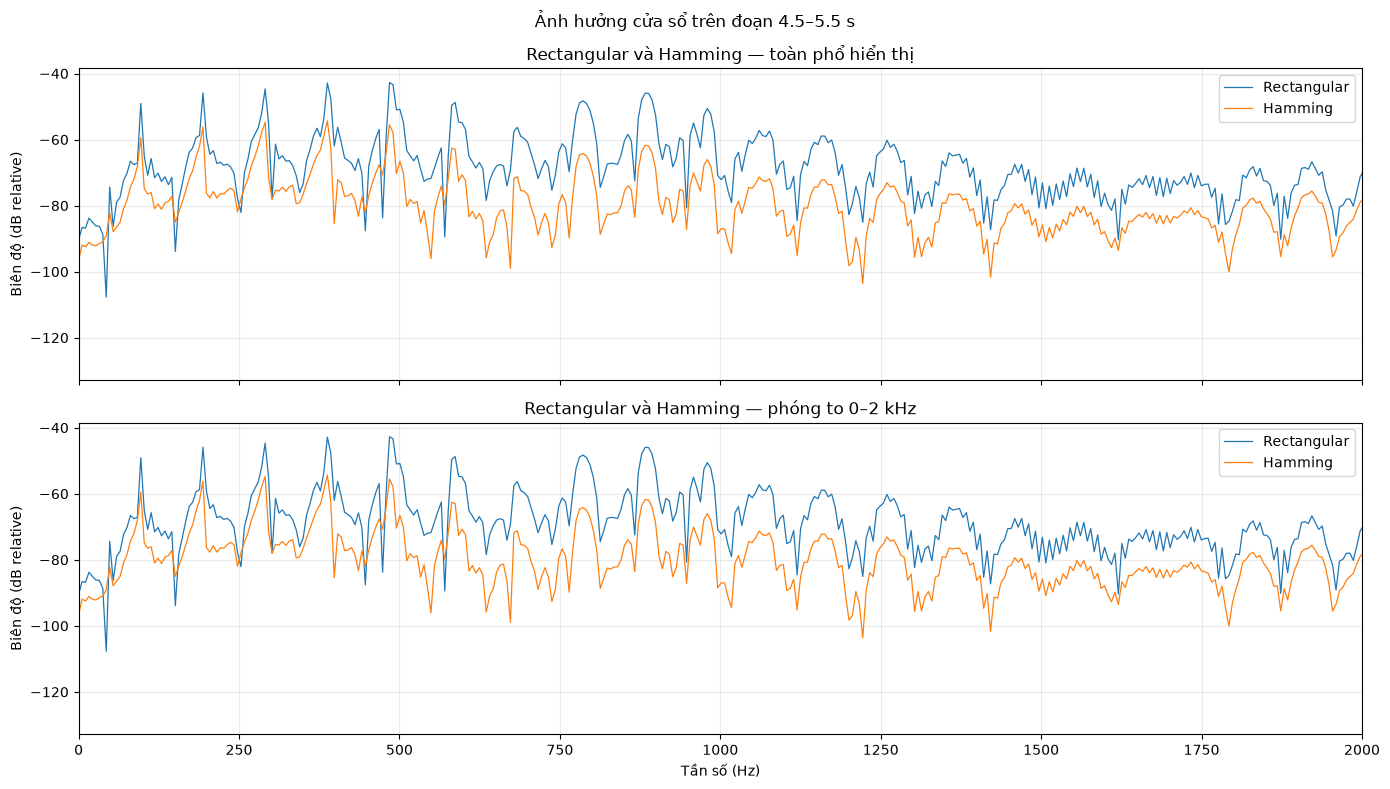

In [19]:
window_nfft = 8192
window_specs = {
    'Rectangular': np.ones(len(segment)),
    'Hamming': np.hamming(len(segment)),
}
window_results = {}
for name, window_values in window_specs.items():
    spectrum = np.fft.rfft(segment * window_values, n=window_nfft)
    frequencies = np.fft.rfftfreq(window_nfft, d=1 / sample_rate)
    magnitude = 2 * np.abs(spectrum) / np.sum(window_values)
    magnitude[0] /= 2
    window_results[name] = (frequencies, 20 * np.log10(np.maximum(magnitude, 1e-12)))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
plot_mask = frequencies <= min(sample_rate / 2, 8000)
for name, (frequencies, magnitude_db) in window_results.items():
    axes[0].plot(frequencies[plot_mask], magnitude_db[plot_mask], label=name, linewidth=0.9)
    axes[1].plot(frequencies[plot_mask], magnitude_db[plot_mask], label=name, linewidth=0.9)
axes[0].set_title('Rectangular và Hamming — toàn phổ hiển thị')
axes[1].set_title('Rectangular và Hamming — phóng to 0–2 kHz')
axes[1].set_xlim(0, min(2000, sample_rate / 2))
for axis in axes:
    axis.set_ylabel('Biên độ (dB relative)')
    axis.grid(alpha=0.25)
    axis.legend()
axes[-1].set_xlabel('Tần số (Hz)')
fig.suptitle(f'Ảnh hưởng cửa sổ trên đoạn {segment_start_s:.1f}–{stop / sample_rate:.1f} s')
fig.tight_layout()
fig.savefig(figures_dir / 'window_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

### Nhận xét bước E

Cửa sổ rectangular có main-lobe hẹp hơn nhưng side-lobe cao, nên spectral leakage rõ hơn. Cửa sổ Hamming hạ side-lobe và giảm leakage, đổi lại main-lobe rộng hơn nên hai đỉnh gần nhau khó tách hơn. Hai phổ được tính trên cùng đoạn dữ liệu và cùng `NFFT` để việc so sánh công bằng.

## F. Lọc số FIR

Thiết kế một FIR low-pass cutoff 2 kHz và một FIR high-pass cutoff 3 kHz, đều dài 201 taps với cửa sổ Hamming. Tín hiệu sau lọc được lưu thành WAV để nghe thử; đáp ứng tần số và phổ trước/sau lọc được vẽ cùng tham số.

FIR taps: 201; group delay ≈ 100 mẫu (2.27 ms)
Low-pass coefficients (5 đầu): [-5.5690e-05  1.6500e-05  8.9740e-05  1.5924e-04  2.2009e-04]
High-pass coefficients (5 đầu): [2.4075e-04 2.5670e-04 2.2754e-04 1.5634e-04 5.2990e-05]


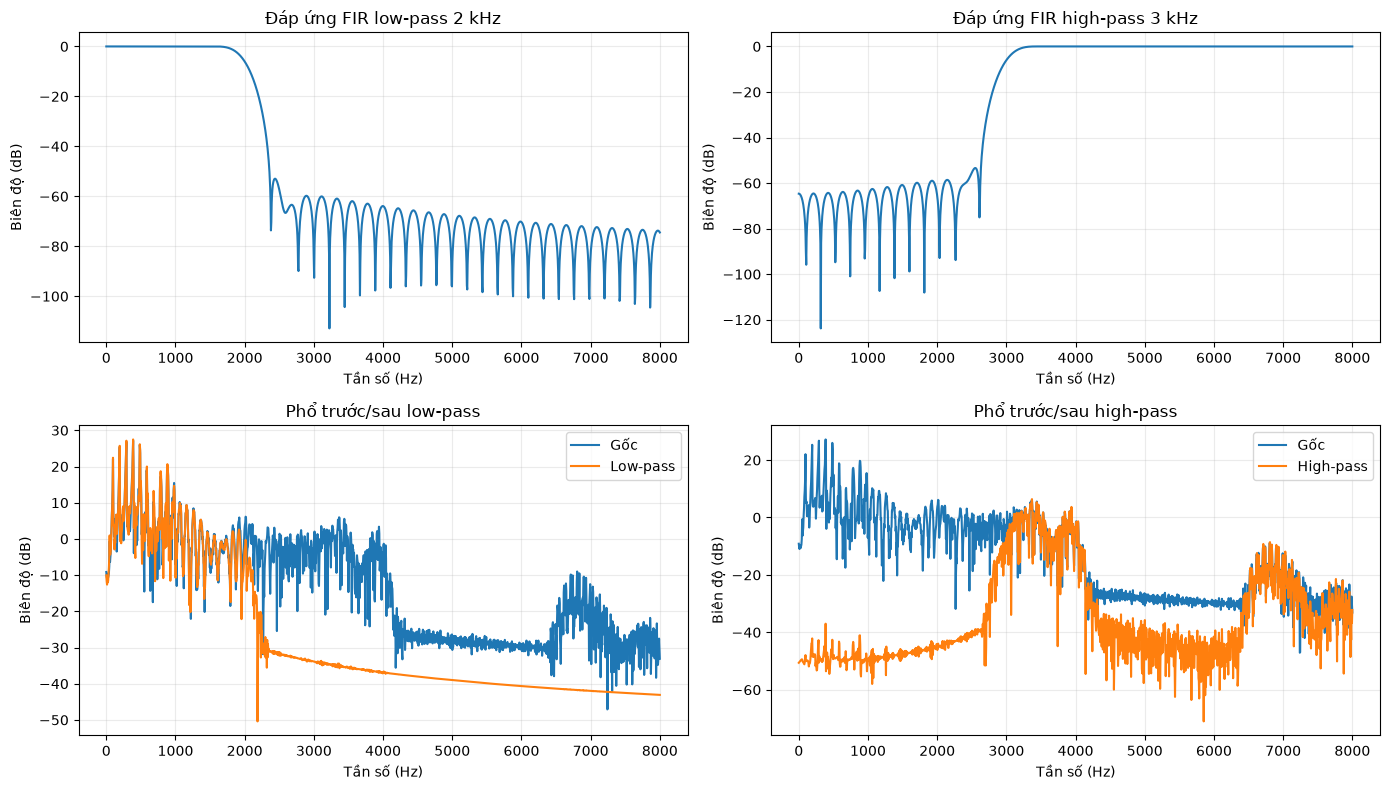

In [20]:
import soundfile as sf

output_dir.mkdir(parents=True, exist_ok=True)
numtaps = 201
lowpass_cutoff_hz = 2000
highpass_cutoff_hz = 3000
b_lowpass = signal.firwin(numtaps, lowpass_cutoff_hz, fs=sample_rate, window='hamming', pass_zero=True)
b_highpass = signal.firwin(numtaps, highpass_cutoff_hz, fs=sample_rate, window='hamming', pass_zero=False)
y_lowpass = signal.lfilter(b_lowpass, [1.0], x_mono)
y_highpass = signal.lfilter(b_highpass, [1.0], x_mono)

sf.write(output_dir / 'speech_lpf_2k.wav', np.clip(y_lowpass, -1, 1), sample_rate, subtype='PCM_16')
sf.write(output_dir / 'speech_hpf_3k.wav', np.clip(y_highpass, -1, 1), sample_rate, subtype='PCM_16')

response_frequencies, response_lowpass = signal.freqz(b_lowpass, worN=4096, fs=sample_rate)
_, response_highpass = signal.freqz(b_highpass, worN=4096, fs=sample_rate)
filter_start = start
filter_stop = filter_start + len(segment)
nfft_filter = 8192
fft_frequency = np.fft.rfftfreq(nfft_filter, d=1 / sample_rate)
hamming_segment = np.hamming(len(segment))
original_spectrum_db = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(segment * hamming_segment, n=nfft_filter)), 1e-12))
lowpass_spectrum_db = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(y_lowpass[filter_start:filter_stop] * hamming_segment, n=nfft_filter)), 1e-12))
highpass_spectrum_db = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(y_highpass[filter_start:filter_stop] * hamming_segment, n=nfft_filter)), 1e-12))

print(f'FIR taps: {numtaps}; group delay ≈ {(numtaps - 1) / 2:.0f} mẫu ({(numtaps - 1) / (2 * sample_rate) * 1000:.2f} ms)')
print('Low-pass coefficients (5 đầu):', np.round(b_lowpass[:5], 8))
print('High-pass coefficients (5 đầu):', np.round(b_highpass[:5], 8))

display_mask = response_frequencies <= min(sample_rate / 2, 8000)
spectrum_mask = fft_frequency <= min(sample_rate / 2, 8000)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(response_frequencies[display_mask], 20 * np.log10(np.maximum(np.abs(response_lowpass[display_mask]), 1e-12)))
axes[0, 0].set_title('Đáp ứng FIR low-pass 2 kHz')
axes[0, 1].plot(response_frequencies[display_mask], 20 * np.log10(np.maximum(np.abs(response_highpass[display_mask]), 1e-12)))
axes[0, 1].set_title('Đáp ứng FIR high-pass 3 kHz')
axes[1, 0].plot(fft_frequency[spectrum_mask], original_spectrum_db[spectrum_mask], label='Gốc')
axes[1, 0].plot(fft_frequency[spectrum_mask], lowpass_spectrum_db[spectrum_mask], label='Low-pass')
axes[1, 0].set_title('Phổ trước/sau low-pass')
axes[1, 1].plot(fft_frequency[spectrum_mask], original_spectrum_db[spectrum_mask], label='Gốc')
axes[1, 1].plot(fft_frequency[spectrum_mask], highpass_spectrum_db[spectrum_mask], label='High-pass')
axes[1, 1].set_title('Phổ trước/sau high-pass')
for axis in axes.flat:
    axis.set_xlabel('Tần số (Hz)')
    axis.set_ylabel('Biên độ (dB)')
    axis.grid(alpha=0.25)
axes[1, 0].legend()
axes[1, 1].legend()
fig.tight_layout()
fig.savefig(figures_dir / 'filter_response.png', dpi=160, bbox_inches='tight')
plt.show()

### Nhận xét bước F

Low-pass giữ năng lượng dưới khoảng 2 kHz nên âm thanh nghe tối và giảm thành phần cao tần. High-pass suy giảm thành phần thấp dưới khoảng 3 kHz nên giọng nghe mỏng hơn. Với 201 taps tại `Fₛ = 44 100 Hz`, độ trễ nhóm lý thuyết là 100 mẫu, tương đương khoảng 2,27 ms.

## G. Lượng tử hóa, resampling và mã hóa

Phần này lượng tử hóa ở 4/8/16 bit và đo SNR, resample có anti-aliasing về 16 kHz và 8 kHz, sau đó tính tốc độ bit PCM và nén MP3 128 kbps để so sánh kích thước thực tế.

Quantization results
bits | levels | SNR (dB)
   4 |     16 |     7.65
   8 |    256 |    30.56
  16 |  65536 |    90.61


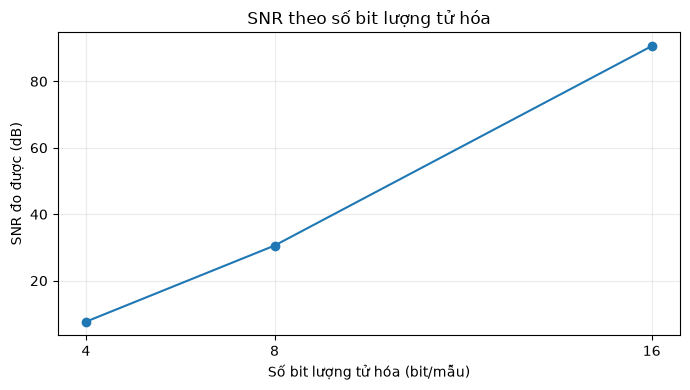

In [21]:
def quantize_signal(signal_values, bits):
    qmax = 2 ** (bits - 1) - 1
    return np.round(np.clip(signal_values, -1, 1) * qmax) / qmax

def calculate_snr_db(reference, processed):
    error = processed - reference
    signal_power = np.sum(reference ** 2)
    noise_power = np.sum(error ** 2)
    return 10 * np.log10(signal_power / max(noise_power, 1e-30))

quantization_rows = []
for bits in (4, 8, 16):
    quantized = quantize_signal(x_mono, bits)
    snr = calculate_snr_db(x_mono, quantized)
    sf.write(output_dir / f'speech_quantized_{bits}bit.wav', quantized, sample_rate, subtype='PCM_16')
    quantization_rows.append((bits, 2 ** bits, snr))

print('Quantization results')
print('bits | levels | SNR (dB)')
for bits, levels, snr in quantization_rows:
    print(f'{bits:>4} | {levels:>6} | {snr:>8.2f}')

quantization_bits = [row[0] for row in quantization_rows]
quantization_snr = [row[2] for row in quantization_rows]
plt.figure(figsize=(7, 4))
plt.plot(quantization_bits, quantization_snr, marker='o')
plt.xticks(quantization_bits)
plt.xlabel('Số bit lượng tử hóa (bit/mẫu)')
plt.ylabel('SNR đo được (dB)')
plt.title('SNR theo số bit lượng tử hóa')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'quantization_snr.png', dpi=160, bbox_inches='tight')
plt.show()

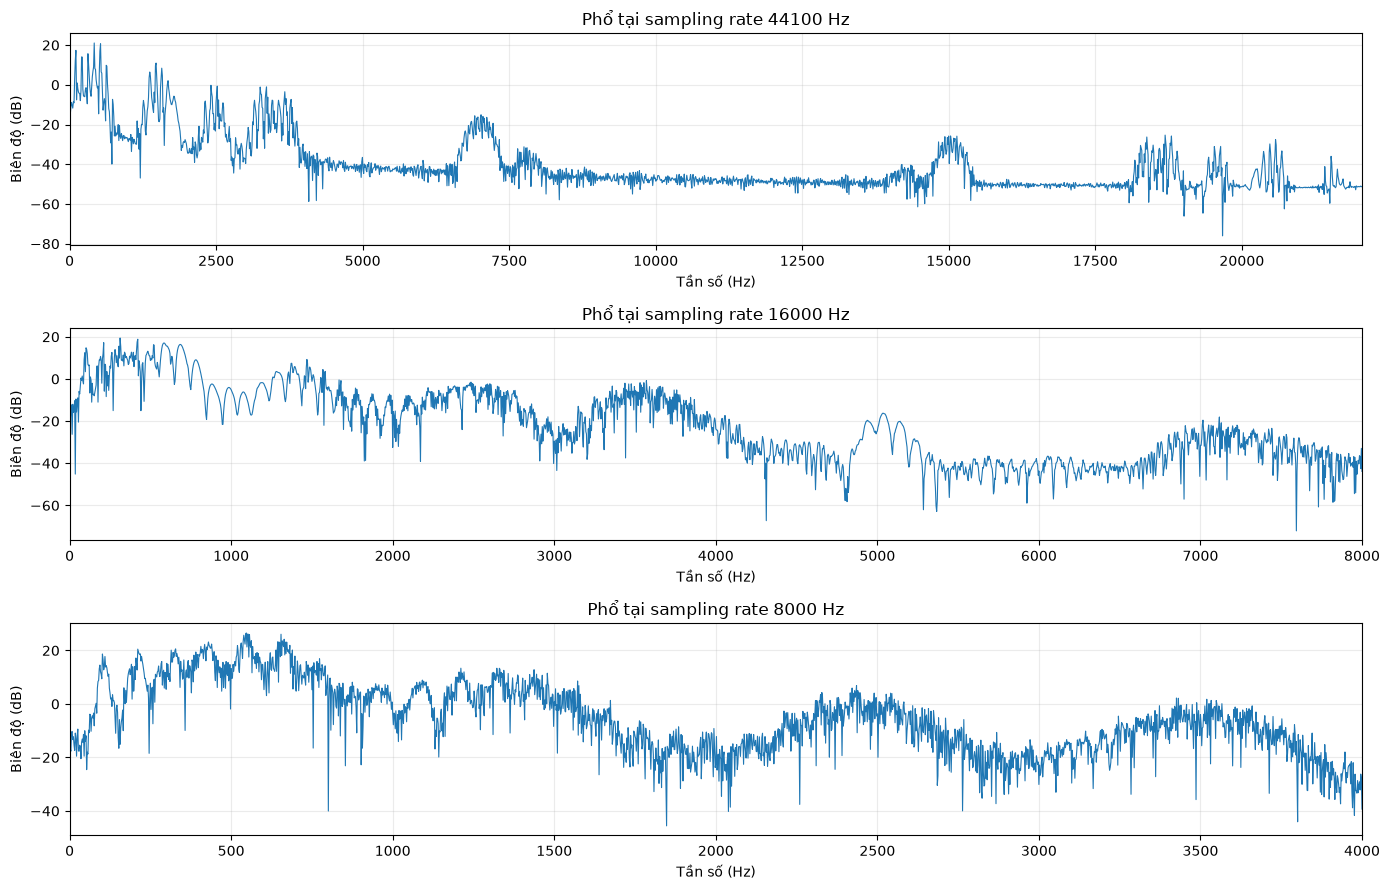

In [22]:
# Resampling bằng resample_poly: có lọc chống aliasing trước khi giảm Fs.
resampled_signals = {}
for target_rate in (16000, 8000):
    resampled = signal.resample_poly(x_mono, target_rate, sample_rate)
    resampled_signals[target_rate] = resampled
    sf.write(output_dir / f'speech_{target_rate}Hz.wav', np.clip(resampled, -1, 1), target_rate, subtype='PCM_16')

analysis_duration_s = min(1.0, duration_s)
original_analysis = x_mono[:round(analysis_duration_s * sample_rate)]
analysis_signals = {sample_rate: original_analysis}
for target_rate, resampled in resampled_signals.items():
    analysis_signals[target_rate] = resampled[:round(analysis_duration_s * target_rate)]

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for axis, (rate, values) in zip(axes, analysis_signals.items()):
    nfft = 4096
    frequencies = np.fft.rfftfreq(nfft, d=1 / rate)
    spectrum_db = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(values * np.hamming(len(values)), n=nfft)), 1e-12))
    axis.plot(frequencies, spectrum_db, linewidth=0.8)
    axis.set_xlim(0, rate / 2)
    axis.set_title(f'Phổ tại sampling rate {rate} Hz')
    axis.set_xlabel('Tần số (Hz)')
    axis.set_ylabel('Biên độ (dB)')
    axis.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(figures_dir / 'resampling_spectrum.png', dpi=160, bbox_inches='tight')
plt.show()

In [23]:
# Tốc độ bit PCM lý thuyết và nén MP3.
pcm_bitrate_bps = sample_rate * sample_bits * channels
pcm_size_bytes = pcm_bitrate_bps * duration_s / 8
mp3_path = output_dir / 'speech_compressed_128kbps.mp3'
audio.export(mp3_path, format='mp3', bitrate='128k')
mp3_size_bytes = mp3_path.stat().st_size
actual_mp3_bitrate_kbps = mp3_size_bytes * 8 / duration_s / 1000
compression_ratio = pcm_size_bytes / mp3_size_bytes

print(f'PCM bitrate lý thuyết: {pcm_bitrate_bps / 1000:.1f} kbps')
print(f'PCM size lý thuyết: {pcm_size_bytes / 1e6:.3f} MB')
print(f'MP3 size thực tế: {mp3_size_bytes / 1e6:.3f} MB')
print(f'MP3 bitrate đo từ file: {actual_mp3_bitrate_kbps:.1f} kbps')
print(f'Compression ratio PCM/MP3: {compression_ratio:.2f}:1')

PCM bitrate lý thuyết: 705.6 kbps
PCM size lý thuyết: 1.341 MB
MP3 size thực tế: 0.244 MB
MP3 bitrate đo từ file: 128.5 kbps
Compression ratio PCM/MP3: 5.49:1


### Nhận xét bước G

SNR tăng khi tăng số bit vì bước lượng tử nhỏ hơn; mức tăng thực tế không nhất thiết đúng 6 dB/bit do biên độ và phân bố của tín hiệu không lý tưởng. Resampling dùng `resample_poly`, vì vậy có lọc chống aliasing trước khi giảm sampling rate; Nyquist lần lượt là 8 kHz và 4 kHz. Tốc độ bit PCM phụ thuộc `Fₛ × B × C`, còn MP3 đạt kích thước nhỏ hơn nhờ mã hóa mất dữ liệu; compression ratio trong notebook được tính từ kích thước PCM lý thuyết và file MP3 thực tế.